# OuviSearch - Entrega 3: Chunking de Manifestações Longas

**Desafio:** Ouvidoria Inteligente - Triagem Semântica de Manifestações Cidadãs <br>
**Disciplina:** Tendências em Ciência da Computação <br>
**Autor:** Pedro Nícollas Pereira Leon Lopes <br>

As 5 manifestações mais longas (> 500 caracteres) reúnem várias denúncias distintas no mesmo texto. Este notebook aplica `RecursiveCharacterTextSplitter` (LangChain) com duas configurações de `(chunk_size, chunk_overlap)`, mede a coesão semântica entre chunks consecutivos e visualiza o resultado em 2D.

## 1. Seleção das 5 manifestações mais longas

In [1]:
# Conjunto de importações
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

with open("../data/manifestacoes.json", encoding="utf-8") as f:
    data = json.load(f)

manifestacoes = data["manifestacoes"]
top5 = sorted(manifestacoes, key=lambda d: -len(d["texto"]))[:5]

pd.DataFrame([{"id": d["id"], "categoria": d["categoria_oficial"], "caracteres": len(d["texto"])} for d in top5])

/tmp/ouvisearch_test_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,categoria,caracteres
0,M004,segurança,761
1,M018,saúde,725
2,M038,meio ambiente,722
3,M009,infraestrutura,718
4,M024,educação,713


## 2. Geração de embeddings (com fallback adicional)

In [2]:
def carregar_modelo_embeddings(nome="paraphrase-multilingual-MiniLM-L12-v2"):
    try:
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(nome), True
    except Exception as e:
        print(f"[aviso] sentence-transformers indisponível ({e}); usando fallback TF-IDF+SVD.")
        return None, False


def gerar_embeddings(textos, nome_modelo="paraphrase-multilingual-MiniLM-L12-v2"):
    modelo, ok = carregar_modelo_embeddings(nome_modelo)
    if ok:
        return np.asarray(modelo.encode(textos, normalize_embeddings=True)), True
    vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode")
    tfidf_matrix = vectorizer.fit_transform(textos)
    n_components = min(30, tfidf_matrix.shape[1] - 1, tfidf_matrix.shape[0] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    denso = svd.fit_transform(tfidf_matrix)
    normas = np.linalg.norm(denso, axis=1, keepdims=True)
    normas[normas == 0] = 1
    return denso / normas, False

## 3. Duas configurações de chunking

In [3]:
CONFIGURACOES = {
    "A: chunk_size=150, overlap=0":  {"chunk_size": 150, "chunk_overlap": 0},
    "B: chunk_size=150, overlap=50": {"chunk_size": 150, "chunk_overlap": 50},
}

resultados = {}
for nome_cfg, params in CONFIGURACOES.items():
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=params["chunk_size"], chunk_overlap=params["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks, owners = [], []
    for d in top5:
        partes = splitter.split_text(d["texto"])
        chunks.extend(partes)
        owners.extend([d["id"]] * len(partes))
    embeddings, usou_reais = gerar_embeddings(chunks)
    resultados[nome_cfg] = {"chunks": chunks, "owners": owners, "embeddings": embeddings}
    print(f"{nome_cfg}: {len(chunks)} chunks gerados no total (modelo real: {usou_reais})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3555.90it/s]

A: chunk_size=150, overlap=0: 34 chunks gerados no total (modelo real: True)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  54%|█████▍    | 108/199 [00:00<00:00, 1074.92it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1425.18it/s]

B: chunk_size=150, overlap=50: 34 chunks gerados no total (modelo real: True)


In [4]:
# Exemplo: os chunks gerados para a manifestação M004, nas duas configurações
for nome_cfg, res in resultados.items():
    print(f"\n=== {nome_cfg} — M004 ===")
    for c, owner in zip(res["chunks"], res["owners"]):
        if owner == "M004":
            print(f"  [{len(c):3d} chars] {c}")


=== A: chunk_size=150, overlap=0 — M004 ===
  [125 chars] Moro na Rua Silvino Lopes, no bairro do Rangel, em João Pessoa, e a situação de segurança piorou muito nos últimos três meses
  [128 chars] . Primeiro, a iluminação pública de quase toda a rua está apagada, o que deixa o ambiente propício para assaltos durante a noite
  [146 chars] . Além disso, já perdi as contas de quantos vizinhos foram assaltados voltando do trabalho, sempre por volta das 19h, na esquina próxima à padaria
  [149 chars] . Outro problema grave é o ponto de venda de drogas que se formou no terreno baldio ao lado da praça, com movimento constante de pessoas estranhas ao
  [ 31 chars] bairro, inclusive durante o dia
  [145 chars] . Já registramos boletim de ocorrência diversas vezes, mas a viatura da polícia quase nunca aparece para rondar a região, mesmo depois de pedidos
  [ 35 chars] formais da associação de moradores.

=== B: chunk_size=150, overlap=50 — M004 ===
  [125 chars] Moro na Rua Silvino Lopes, no b

## 4. Coesão semântica entre chunks consecutivos

In [5]:
def coesao_media(res):
    chunks, owners, embeddings = res["chunks"], res["owners"], res["embeddings"]
    scores = []
    for i in range(len(chunks) - 1):
        if owners[i] == owners[i + 1]:
            s = cosine_similarity(embeddings[i].reshape(1, -1), embeddings[i + 1].reshape(1, -1))[0][0]
            scores.append(s)
    return float(np.mean(scores)), scores


linhas = []
for nome_cfg, res in resultados.items():
    media, _ = coesao_media(res)
    linhas.append({"Configuração": nome_cfg, "Nº de chunks": len(res["chunks"]),
                    "Coesão média entre chunks consecutivos": round(media, 4)})
pd.DataFrame(linhas)

,Configuração,Nº de chunks,Coesão média entre chunks consecutivos
0,"A: chunk_size=150, overlap=0",34,0.2601
1,"B: chunk_size=150, overlap=50",34,0.4142


### Como o overlap influencia a coesão?

Na configuração **A (overlap=0)**, a coesão média entre chunks consecutivos da mesma manifestação foi de **0.2601**; <br>
Na configuração **B (overlap=50)**, subiu para **0.4142**. <br>
Um ganho de cerca de **1,6x**. <br> 

Sem overlap, o texto é cortado exatamente onde acaba o espaço disponível, e um chunk frequentemente termina no meio de uma frase que o próximo apenas continua. <br> Como podemos ver no exemplo de M004, seção 5: A frase *"...a viatura da polícia quase nunca aparece para rodar a região, mesmo depois de pedidos formais..."* fica partida entre dois chunks, sem nenhuma palavra em comum entre eles. <br>
Com overlap, os últimos ~50 caracteres de um chunk se repetem no início do seguinte, dando aos dois vocabulário e contexto compartilhados.

Podemos notar que o ganho é bem mais modesto do que podiamos esperar. Mesmo **sem overlap**, chunks vizinhos já têm coesão 0.26, porque todos pertencem ao mesmo relato (mesma rua, mesmo bairro, mesmo tipo de problema) e um modelo de embeddings real captura essa proximidade temática mesmo com as
palavras sendo diferentes. <br> O overlap **reforça** a costura entre vizinhos, mas não é o que a cria.

**Conclusão:** O overlap funciona como uma "costura"/junção entre chunks adjacentes: Ele não muda o conteúdo novo de cada chunk, mas garante que a fronteira do corte não jogue fora o contexto imediatamente anterior, o que se reflete em maior similaridade de cosseno entre vizinhos.

## 5. Qual configuração preserva melhor o sentido das denúncias?

In [6]:
# Exemplo concreto do problema de cortar sem overlap: o chunk final da configuração A
chunks_a = resultados["A: chunk_size=150, overlap=0"]["chunks"]
owners_a = resultados["A: chunk_size=150, overlap=0"]["owners"]
chunks_b = resultados["B: chunk_size=150, overlap=50"]["chunks"]
owners_b = resultados["B: chunk_size=150, overlap=50"]["owners"]

idx_m004_a = [i for i, o in enumerate(owners_a) if o == "M004"]
print("Config A (sem overlap) — últimos 2 chunks de M004:")
for i in idx_m004_a[-2:]:
    print(f"  {chunks_a[i]!r}")

idx_m004_b = [i for i, o in enumerate(owners_b) if o == "M004"]
print("\nConfig B (overlap=50) — últimos 2 chunks de M004:")
for i in idx_m004_b[-2:]:
    print(f"  {chunks_b[i]!r}")

Config A (sem overlap) — últimos 2 chunks de M004:
  '. Já registramos boletim de ocorrência diversas vezes, mas a viatura da polícia quase nunca aparece para rondar a região, mesmo depois de pedidos'
  'formais da associação de moradores.'

Config B (overlap=50) — últimos 2 chunks de M004:
  '. Já registramos boletim de ocorrência diversas vezes, mas a viatura da polícia quase nunca aparece para rondar a região, mesmo depois de pedidos'
  'para rondar a região, mesmo depois de pedidos formais da associação de moradores.'


Na **configuração A**, o penúltimo chunk de M004 termina em "...mas a viatura da polícia quase nunca aparece para rondar a região, mesmo depois de pedidos" e o último chunk continua isolado em "formais da associação de moradores.". <br>
Assim, a frase fica partida ao meio, sem nenhuma palavra em comum entre os dois chunks para religar o contexto.

Na **configuração B**, o overlap de 50 caracteres faz o último chunk **começar repetindo o fim do chunk anterior** ("para rondar a região, mesmo depois de pedidos formais da associação de moradores."), de modo que o trecho final da frase fica legível dentro de um único chunk, em vez de reduzido ao fragmento "formais da associação de moradores.". <br>

Por isso, a **configuração B (150/50) preserva melhor o sentido das denúncias**: Cada chunk tem mais chance de conter uma ideia completa ou, na pior das hipóteses, compartilhar contexto suficiente com o vizinho para que um sistema de busca semântica não recupere um trecho truncado e sem sentido. O custo é gerar chunks com conteúdo redundante (o texto do overlap aparece duas vezes no índice), o que é um trade-off aceitável para textos curtos como os desta base.

## 6. Visualização 2D dos chunks (PCA e t-SNE)

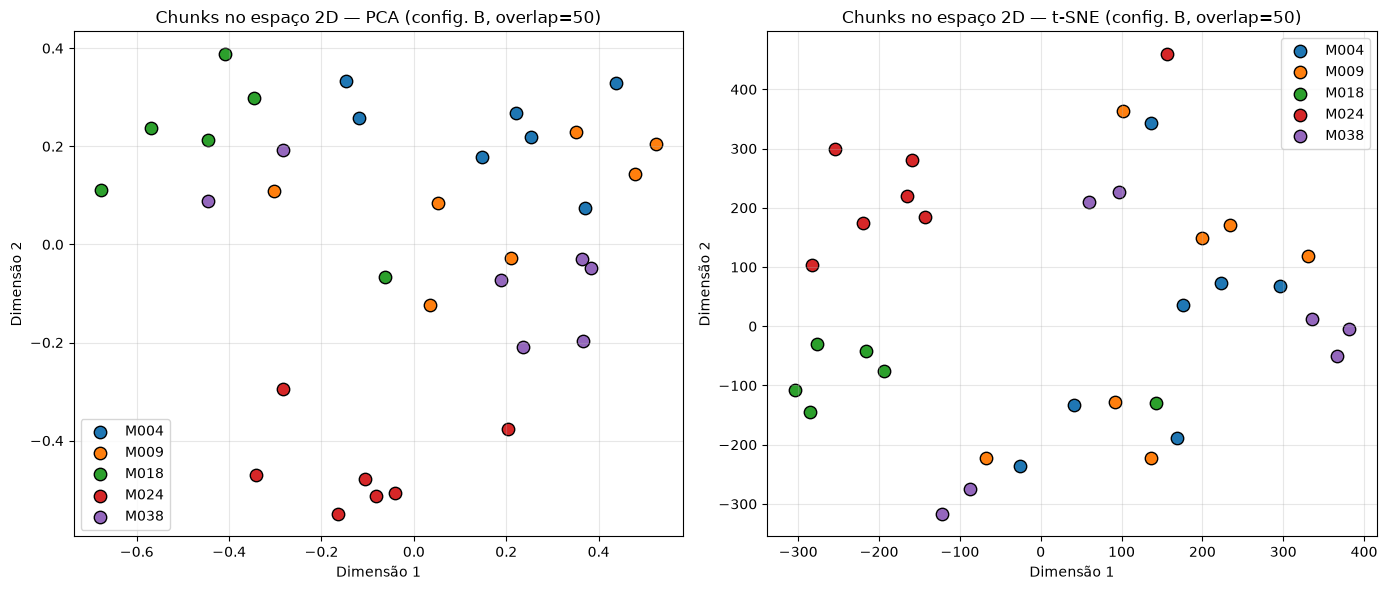

In [7]:
res_b = resultados["B: chunk_size=150, overlap=50"]
chunks, owners, embeddings = res_b["chunks"], res_b["owners"], res_b["embeddings"]

coords_pca = PCA(n_components=2, random_state=42).fit_transform(embeddings)
perplexidade = min(5, len(chunks) - 1)
coords_tsne = TSNE(n_components=2, perplexity=perplexidade, random_state=42, init="pca").fit_transform(embeddings)

ids_unicos = sorted(set(owners))
cores = {doc_id: cor for doc_id, cor in zip(ids_unicos, plt.cm.tab10.colors)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, titulo in [(axes[0], coords_pca, "PCA"), (axes[1], coords_tsne, "t-SNE")]:
    for doc_id in ids_unicos:
        pontos = [coords[i] for i in range(len(owners)) if owners[i] == doc_id]
        pontos = np.array(pontos)
        ax.scatter(pontos[:, 0], pontos[:, 1], label=doc_id, s=80, color=cores[doc_id], edgecolor="black")
    ax.set_title(f"Chunks no espaço 2D — {titulo} (config. B, overlap=50)")
    ax.set_xlabel("Dimensão 1")
    ax.set_ylabel("Dimensão 2")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../assets/chunks_2d.png", dpi=150)
plt.show()

In [8]:
# Quantifica a pergunta: os chunks de uma mesma manifestação ficam mais próximos entre si
# do que de chunks de outras manifestações? (no espaço original, não nas projeções 2D)
sim_chunks = cosine_similarity(embeddings)
intra, inter = [], []
for i in range(len(chunks)):
    for j in range(i + 1, len(chunks)):
        (intra if owners[i] == owners[j] else inter).append(sim_chunks[i, j])

acertos = 0
for i in range(len(chunks)):
    s = sim_chunks[i].copy()
    s[i] = -1
    acertos += owners[int(np.argmax(s))] == owners[i]

print(f"Similaridade média entre chunks da MESMA manifestação:      {np.mean(intra):.4f}")
print(f"Similaridade média entre chunks de manifestações DIFERENTES: {np.mean(inter):.4f}")
print(f"Vizinho mais próximo pertence à mesma manifestação: {acertos}/{len(chunks)} ({acertos/len(chunks):.0%})")

Similaridade média entre chunks da MESMA manifestação:      0.3221
Similaridade média entre chunks de manifestações DIFERENTES: 0.1850
Vizinho mais próximo pertence à mesma manifestação: 21/34 (62%)


**Os chunks de uma mesma manifestação ficam próximos?** 

Em boa medida, sim, mas não de forma perfeita. <br>

Medido no espaço original (antes da projeção 2D), chunks da mesma manifestação têm similaridade média de **0.32**, contra **0.19** entre chunks de manifestações diferentes, e em **21 dos 34 chunks (62%)** o vizinho mais próximo pertence à mesma manifestação de origem. <br> 

Nas projeções PCA e t-SNE isso aparece como agrupamentos parciais por cor, com bastante mistura.

Isso se deve ao fato de, cada manifestação longa junta vários subproblemas (ex.: M004 fala de iluminação, assaltos e tráfico na mesma denúncia), então um chunk sobre "iluminação apagada" de M004 pode ficar mais perto de um chunk sobre "poste apagado" de M009 do que de outro chunk de M004 sobre tráfico de drogas. <br>

Para busca semântica isso é, na prática, o comportamento desejado: Recuperar por **conteúdo**, não por documento de origem. E é justamente o que o chunking permite que a indexação do texto inteiro, como um único bloco, não permitiria.